In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pdbtools
import potential
import torch
import torch.nn as nn
from icemaker import Icemaker, radial_profile_3d
from scipy.interpolate import CubicSpline
from skimage.feature import peak_local_max
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

In [2]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    idx_interval = idx_length // nslices
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.8), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    # plt.suptitle(f"Slices along axis {axis}")
    plt.show()

In [3]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Try class

In [4]:
n = 200
dx = 0.5
icemake = Icemaker(n=n, dx=dx)

In [5]:
source = 'torch'
filepath = 'ice-data/mdsim_f_kernel_averaged_200x200x200_0.5A.pt'

# source = 'dump'
# filepath = '/scratch/loh/joel/czii/stackingDisordered_20x20x20.MW_temp400.dump'

In [6]:
icemake.get_mdsim_averaged_f_kernel(filepath, source=source)

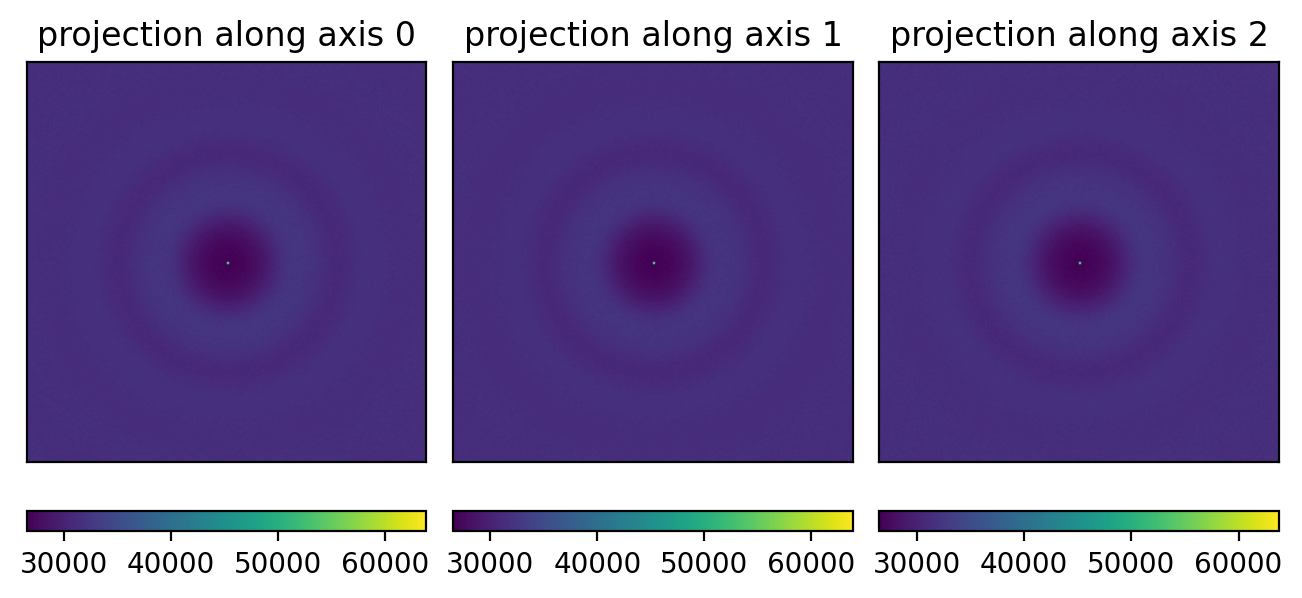

In [7]:
plot3d(icemake.mdsim_ice_deltas_f)

In [8]:
mdsim_ice_deltas_f_abs_avg_radial = radial_profile_3d(icemake.mdsim_ice_deltas_f)

In [9]:
k = torch.arange(len(mdsim_ice_deltas_f_abs_avg_radial)) * icemake.mdsim_dk

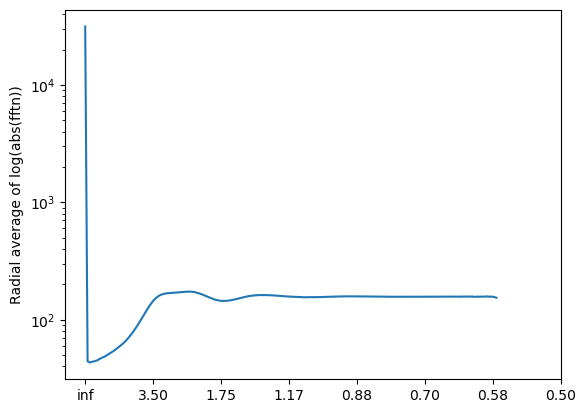

In [10]:
nticks = 8
maxk = 2
plt.semilogy(k, mdsim_ice_deltas_f_abs_avg_radial)
plt.xticks(
    torch.linspace(0, maxk, nticks),
    labels=[f"{1/k:.2f}" for k in torch.linspace(0, maxk, nticks)],
)
plt.ylabel("Radial average of log(abs(fftn))")
plt.show()

## Interpolate to larger FOV

In [11]:
n = 200
dx = 0.5

In [12]:
icemake.interpolate_mdsim_f_kernel(n, dx)

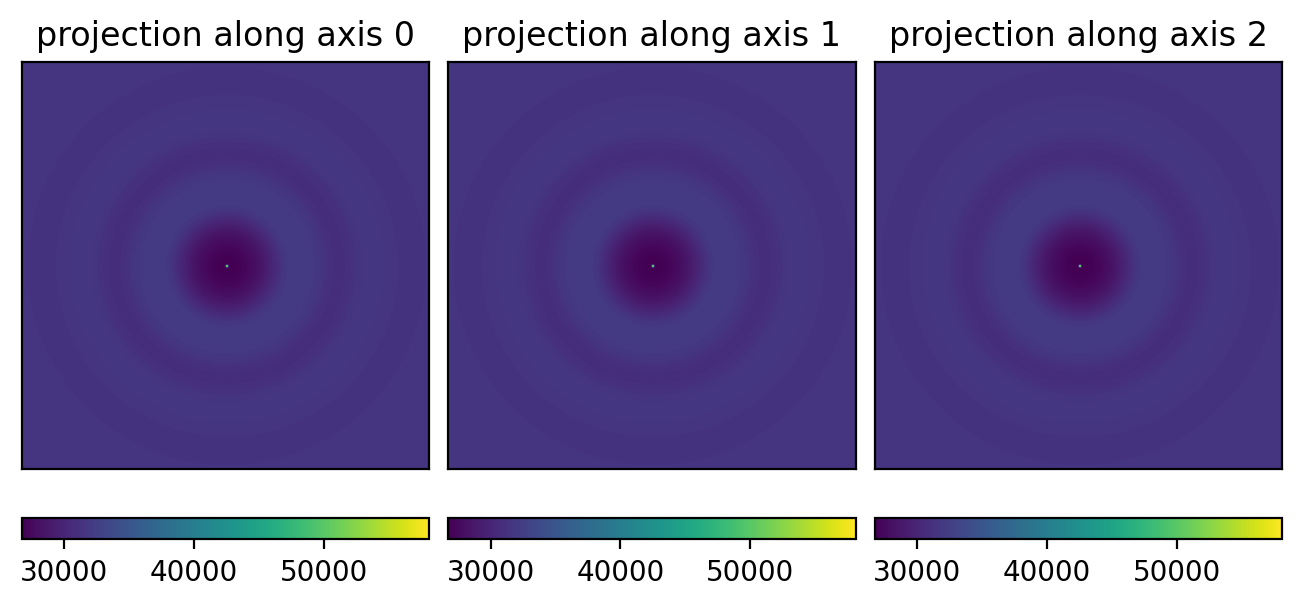

In [13]:
plot3d(icemake.interp_f_kernel)

## Generate initial positions

In [14]:
icemake.create_initial_ice_volume(n=n, dx=dx)

In [17]:
icemake.generate_ice(n=n, dx=dx, min_distance=int(1.5//dx))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:21<00:00,  4.21s/it]


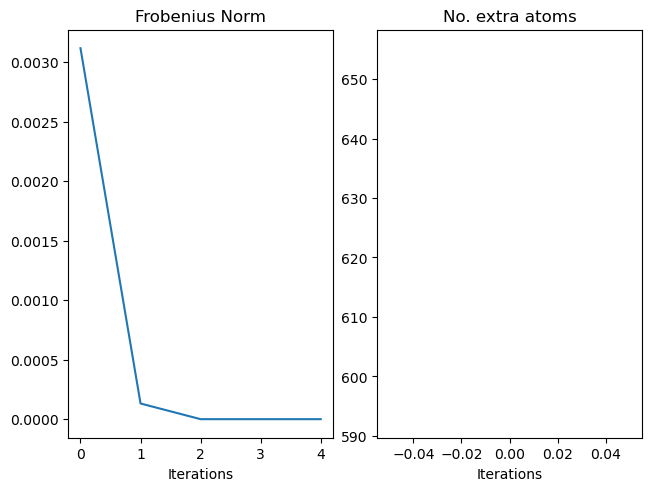

In [18]:
fig, axes = plt.subplots(1, 2, constrained_layout=True)
ax = axes[0]
ax.plot(icemake.frob_norm)
ax.set_title("Frobenius Norm")
ax.set_xlabel("Iterations")

ax = axes[1]
ax.plot(icemake.n_extra_atoms)
ax.set_title("No. extra atoms")
ax.set_xlabel("Iterations")
plt.show()

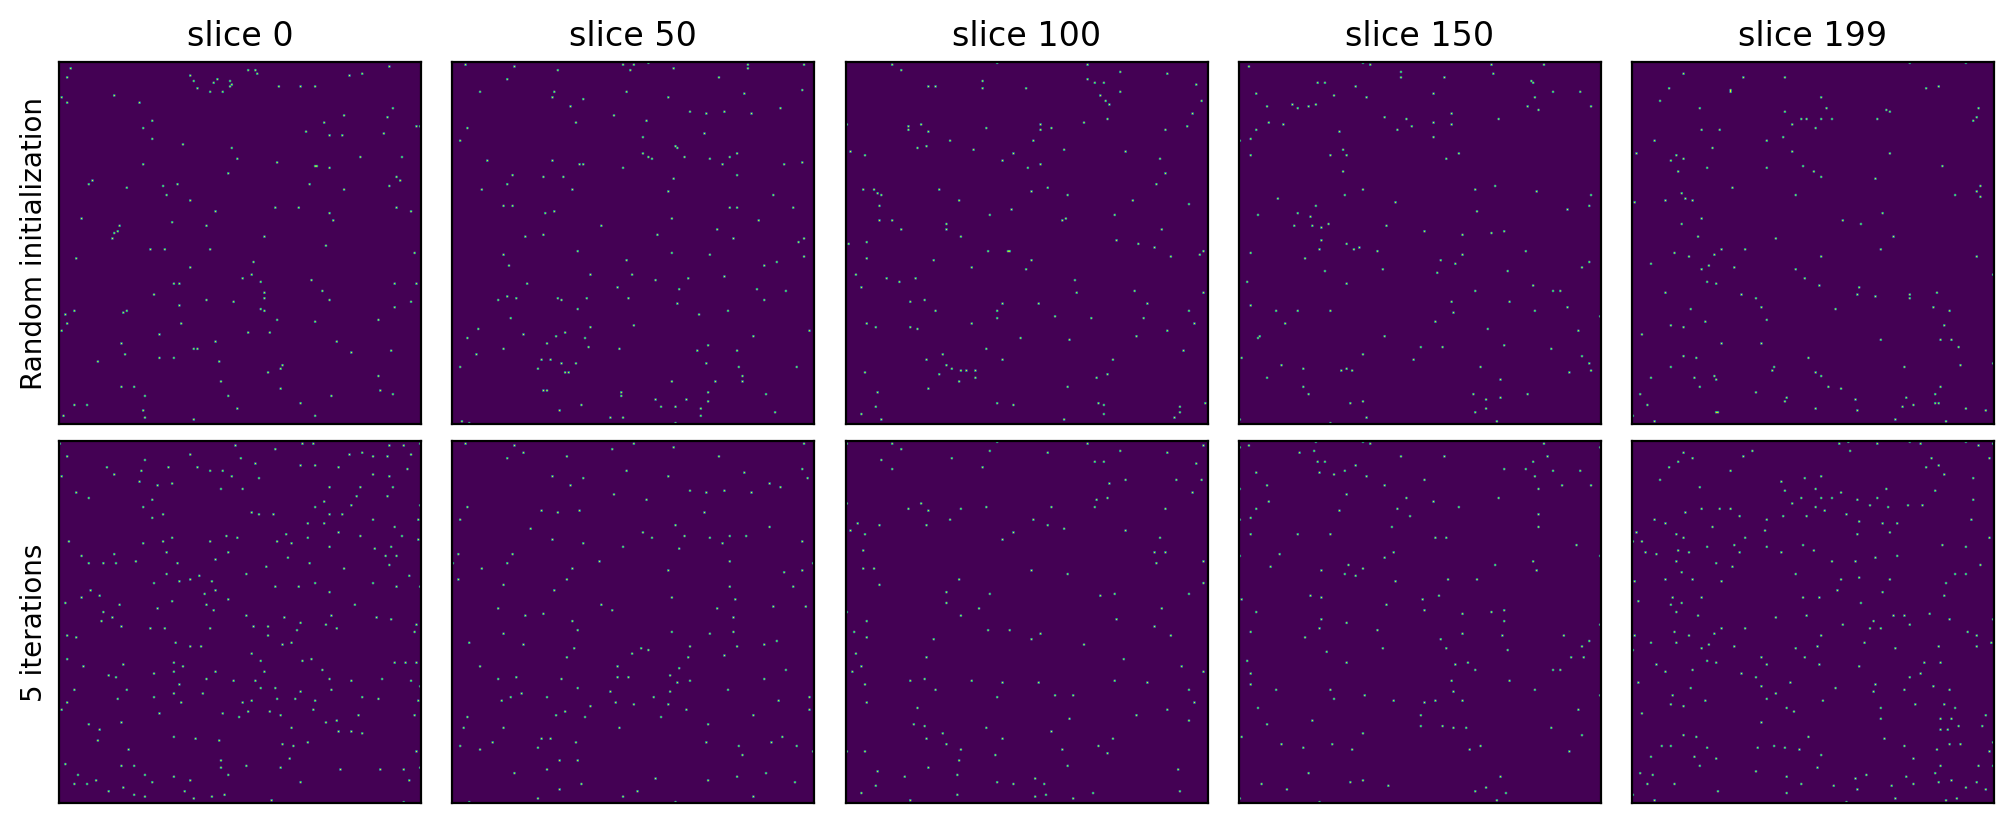

In [20]:
fig, axes = plt.subplots(2, 5, constrained_layout=True, figsize=(10, 4), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(5):
    if i == 4:
        idx = n-1
    else:
        idx = i * n//4
    ax = axes[0, i]
    ax.imshow(icemake.ice_vol_init[idx])
    ax.set_title(f"slice {idx}")

    ax = axes[1, i]
    ax.imshow(icemake.current_ice_vol[idx])
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{icemake.niter} iterations")
plt.show()

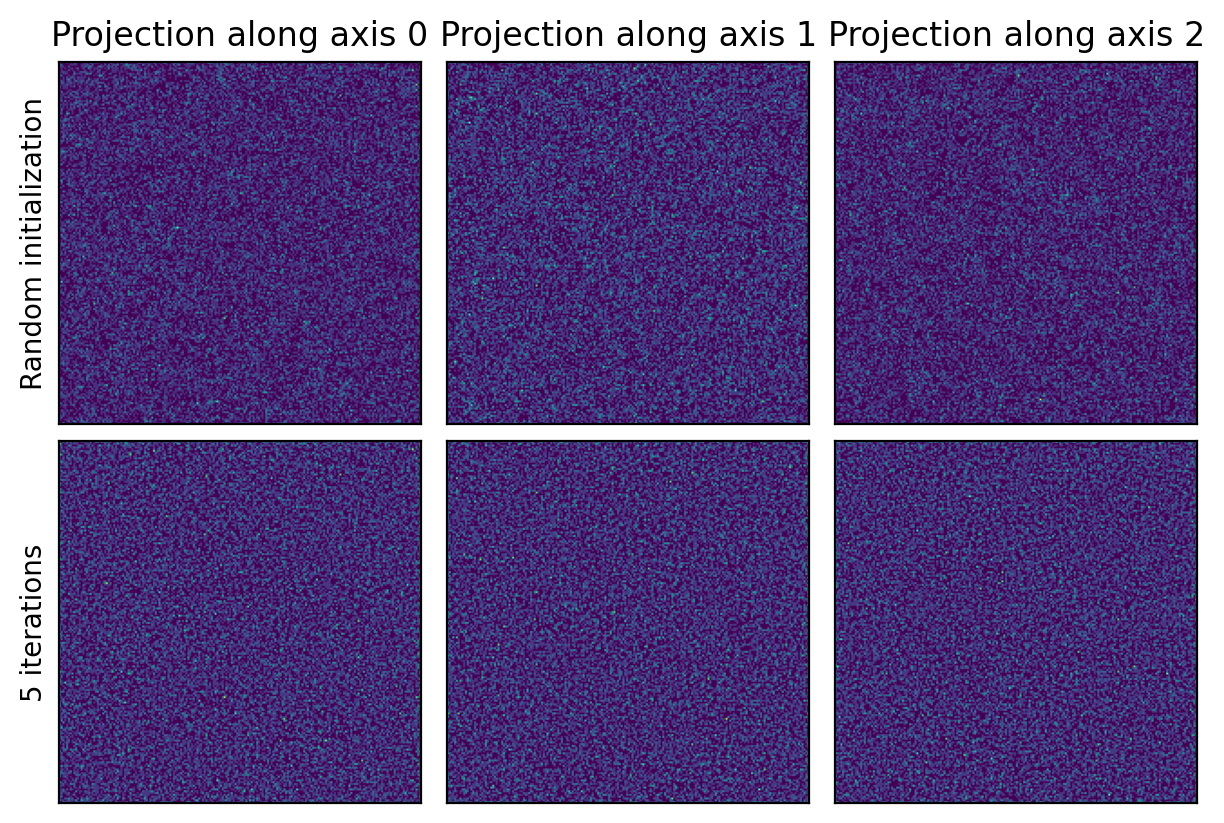

In [21]:
fig, axes = plt.subplots(2, 3, constrained_layout=True, figsize=(6, 4), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(icemake.ice_vol_init.sum(dim=i))
    ax.set_title(f"Projection along axis {i}")

    ax = axes[1, i]
    ax.imshow(icemake.current_ice_vol.sum(dim=i))
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{icemake.niter} iterations")
plt.show()

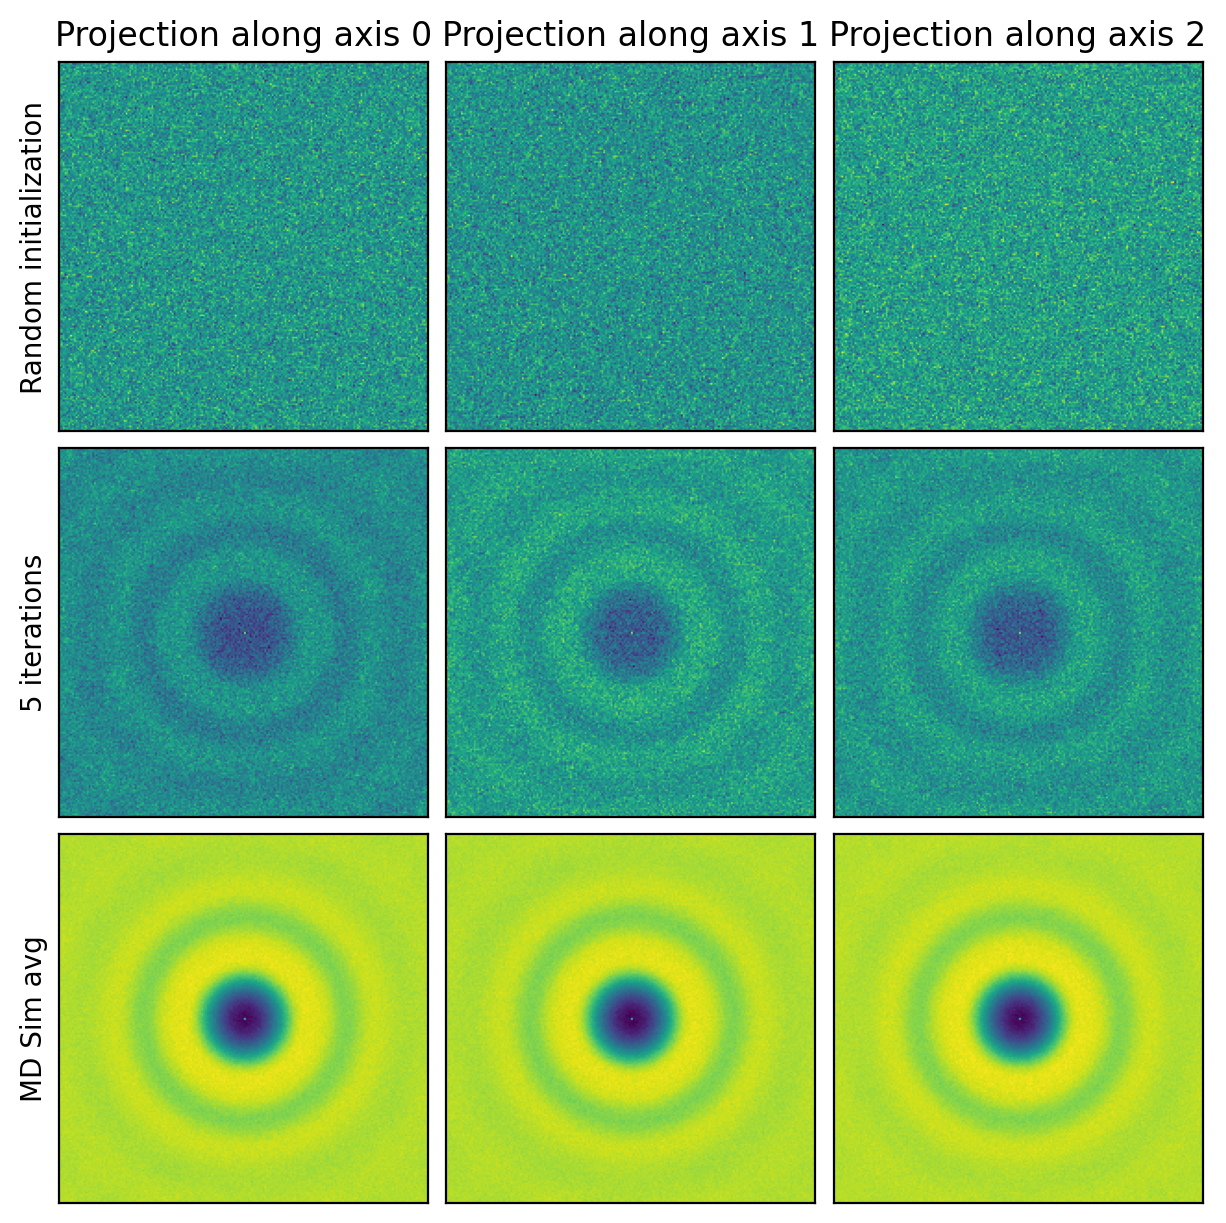

In [22]:
ice_vol_init_logabsf = torch.log(torch.abs(fftn(icemake.ice_vol_init)))
ice_vol_logabsf = torch.log(torch.abs(fftn(icemake.current_ice_vol)))
mdsim_ice_delta_logabsf_avg = torch.log(torch.abs(icemake.mdsim_ice_deltas_f))

fig, axes = plt.subplots(3, 3, constrained_layout=True, figsize=(6, 6), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(ice_vol_init_logabsf.sum(dim=i))
    ax.set_title(f"Projection along axis {i}")

    ax = axes[1, i]
    ax.imshow(ice_vol_logabsf.sum(dim=i))

    ax = axes[2, i]
    ax.imshow(mdsim_ice_delta_logabsf_avg.sum(dim=i))
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{5} iterations")
axes[2, 0].set_ylabel("MD Sim avg")
plt.show()

In [25]:
current_ice_vol_f_abs_radial = radial_profile_3d(torch.abs(fftn(icemake.current_ice_vol)))

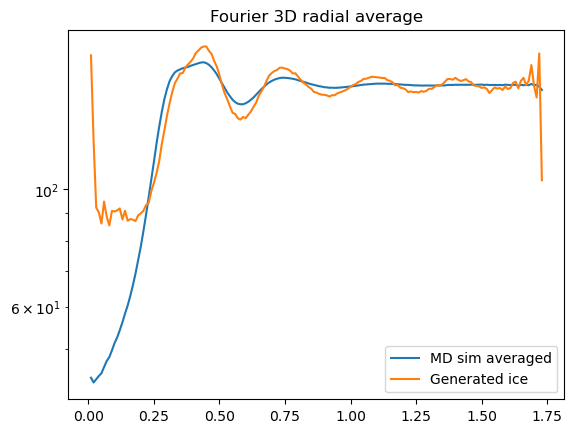

In [28]:
plt.semilogy(k[1:], mdsim_ice_deltas_f_abs_avg_radial[1:], label='MD sim averaged')
plt.semilogy(k[1:], current_ice_vol_f_abs_radial[1:], label='Generated ice')
plt.title('Fourier 3D radial average')
plt.legend()